In [199]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot
sns.set(rc={'figure.figsize':(11.7,8.27)})


In [200]:
summary = pd.read_csv("../model_summary.csv")
pd.options.display.max_rows = 999

In [201]:
oct_presence = "Usando OCT"
double_img = "duas_imagens"

In [202]:
summary["output_tab"].unique()

array([nan,  5.])

In [203]:
summary.drop_duplicates(inplace=True)
summary["output_tab"] = summary["output_tab"].fillna(0)
summary["double_img"] = summary["double_img"].fillna(0)

In [204]:
summary[oct_presence] = np.where(summary['output_tab'] > 0, 'Sim', 'Não')

In [205]:
summary[double_img] = summary["double_img"].map({0.0: "Não",1.0: "Sim"})

In [206]:
summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'is_inception', 'optim',
       'lr', 'epochs', 'double_img', 'output_tab', 'backbone',
       'feature_extract', 'early_start', 'Usando OCT', 'duas_imagens'],
      dtype='object')

In [196]:
summary.shape

(536, 31)

In [215]:
tmp_summary = summary[summary['backbone'].str.contains("mobile|shuffle|efficient|vit|inception|resnet")==True]


In [216]:
tmp_summary.to_csv("tmp_summary.csv",index=False)

In [213]:
summary["backbone"].unique()

array(['regnet', 'mobile', 'shuffle', 'efficient', 'regnet16', 'regnet32',
       'inception', 'vit', 'resnet', nan, 'regnetx', 'regnet16x',
       'regnet32x'], dtype=object)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'regnet'),
  Text(1, 0, 'mobile'),
  Text(2, 0, 'shuffle'),
  Text(3, 0, 'efficient'),
  Text(4, 0, 'regnet16'),
  Text(5, 0, 'regnet32'),
  Text(6, 0, 'inception'),
  Text(7, 0, 'vit'),
  Text(8, 0, 'resnet'),
  Text(9, 0, 'regnetx'),
  Text(10, 0, 'regnet16x'),
  Text(11, 0, 'regnet32x')])

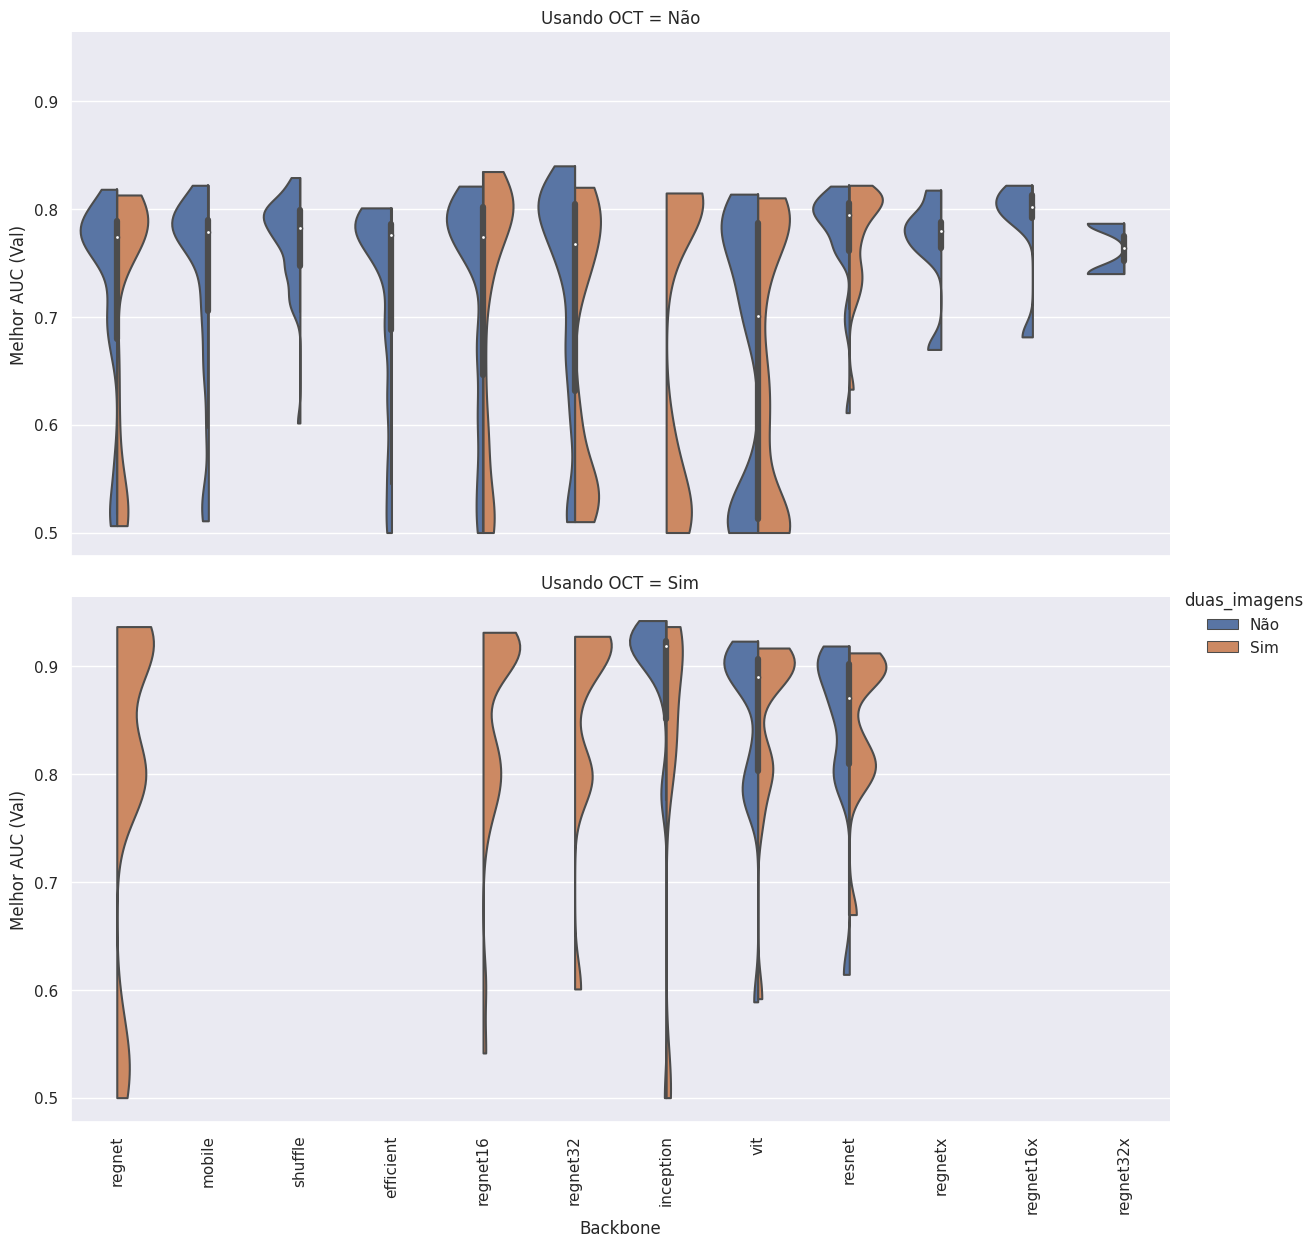

In [198]:

g = sns.catplot(
    data=summary, x="backbone", y="val_best_auc", hue=double_img,row=oct_presence,
    kind="violin", bw=.25, cut=0, split=True,aspect=2,height=6,
)

g.set_ylabels("Melhor AUC (Val)", fontsize=12) # not set_label
g.set_xlabels("Backbone", fontsize=12) # not set_label
pyplot.xticks(rotation=90)




# Benefícios 

- Regnet é flexível, e é possível escolher arquiteturas que contém masi parametros de treinamento para melhor acurácia 
- Pode ser usada em grande escala
- Pode ser utilizada em dispositivos pequenos como Mobile 
- Pode ser treinado com um número menor de imagens, sem a necessidade de coletar um número grande. 
- É eficiente, considerando a tabela abaixo
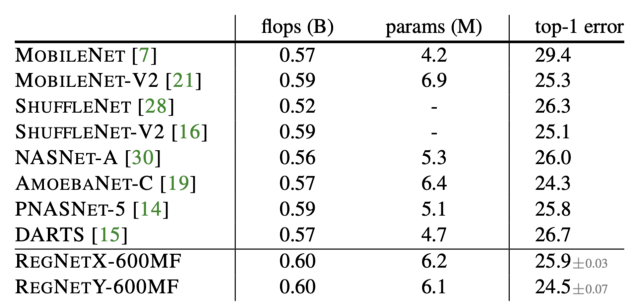
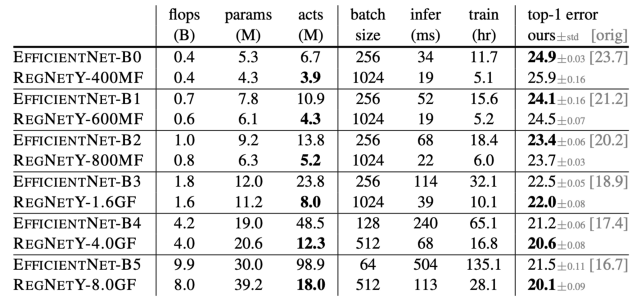